# MIG Cement Demand Forecasting — Step 5: Model Development

**Scope of this notebook:** the brief asks for a SARIMAX baseline compared against "machine
learning approaches **including** Random Forest" — that wording leaves room for more than one
ML model, so this notebook builds **four** models rather than two:

1. **Seasonal-naive baseline** — no fitting at all, just repeats last week's pattern. Every
   forecasting project needs a floor like this: if a sophisticated model can't beat "just repeat
   last week," the sophistication isn't earning its keep.
2. **SARIMAX** — the brief's named statistical baseline, with exogenous regressors.
3. **Random Forest** — the brief's named ML approach.
4. **Gradient Boosting** (`HistGradientBoostingRegressor`) — a stronger tree ensemble, a natural
   "we also tried a more powerful model" step, especially useful here since neither of the first
   two models alone reached the brief's accuracy target.

All four are evaluated against a genuine **8-week (56-day) ahead** forecast, and the best is
selected against the target of **MAPE ≤ 15%**.

**A modelling choice worth stating up front:** "8 weeks ahead" means generating the *entire*
56-day forecast from a single point in time, without ever seeing the real outcomes as those 56
days unfold — materially harder than a rolling one-step forecast that gets to peek at
yesterday's actual result before predicting today. SARIMAX forecasts multiple steps natively.
The tree-based models don't, so we forecast **recursively** — each day's prediction becomes an
input to the next day's lag features, exactly as it would work in production.

**A leakage decision worth flagging too:** the cleaned/engineered datasets also contain
inventory columns (`closing_inventory_tonnes`, `capacity_utilization`, `over_capacity`, etc.).
We deliberately **exclude all of these** from the feature set below. `closing_inventory_tonnes`
is algebraically derived from `consumed_tonnes` itself (`closing = opening + deliveries −
consumed`) — including it would let the model see the answer. Demand forecasting predicts
`consumed_tonnes` from the *schedule, weather, history, and site behaviour* — inventory
projection is a separate, downstream problem, handled properly in Step 6 using this model's
*output* as an input, not the other way around.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
import os

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
np.random.seed(42)


In [4]:
import os
print(os.listdir("../outputs"))

['.gitkeep', 'cement_demand_clean.db', 'cement_demand_clean.parquet', 'cement_demand_features.parquet']


## 1. Load Data and Define the Train/Test Split

We use a **time-based split** (never random — that would leak future information into
training): the final 56 days of the dataset are held out entirely as the test/forecast horizon,
matching the brief's 8-week target exactly.


In [5]:
clean = pd.read_parquet("../outputs/cement_demand_clean.parquet")
features = pd.read_parquet("../outputs/cement_demand_features.parquet")

TEST_HORIZON = 56  # 8 weeks
max_date = clean["date"].max()
test_start = max_date - pd.Timedelta(days=TEST_HORIZON - 1)

train_features = features[features["date"] < test_start].copy()
test_dates = pd.date_range(test_start, max_date, freq="D")

sites = sorted(clean["site_id"].unique())

print(f"Full range: {clean['date'].min().date()} to {clean['date'].max().date()}")
print(f"Test window: {test_start.date()} to {max_date.date()}  ({TEST_HORIZON} days)")
print(f"Sites: {len(sites)}")
print(f"Training rows (post warm-up): {len(train_features)}")


Full range: 2022-01-01 to 2024-12-31
Test window: 2024-11-06 to 2024-12-31  (56 days)
Sites: 30
Training rows (post warm-up): 30360


## 2. Feature Set — Explicit and Leakage-Free

Only information genuinely available *before* a day's consumption happens: the planned
schedule, weather, calendar position, site behaviour/region, and lagged/rolling history of past
consumption. No same-day inventory columns.


In [6]:
FEATURE_COLS = [
    "planned_pour_tonnes", "rain_mm", "avg_temp_c",
    "consumed_lag_1", "consumed_lag_7", "consumed_lag_14", "consumed_lag_28",
    "consumed_roll_mean_7", "consumed_roll_mean_14", "consumed_roll_mean_28",
    "consumed_roll_std_7", "consumed_roll_std_14", "consumed_roll_std_28",
    "rain_roll_sum_3", "is_heavy_rain", "is_near_freezing",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "demand_pressure_ratio",
    "behavior_aggressive", "behavior_chaotic", "behavior_conservative",
    "region_East", "region_North", "region_South", "region_West",
]
TARGET = "consumed_tonnes"

missing = [c for c in FEATURE_COLS if c not in train_features.columns]
assert not missing, f"Missing expected feature columns: {missing}"
print(f"{len(FEATURE_COLS)} feature columns confirmed present.")


28 feature columns confirmed present.


## 3. Model 1 — Seasonal-Naive Baseline

The simplest defensible forecast: repeat each site's last real 7-day pattern, cycled across the
full 56-day horizon. No fitting, no parameters — this is the number every other model needs to
beat convincingly to justify its own complexity.


In [7]:
def seasonal_naive_forecast() -> pd.DataFrame:
    rows = []
    for site_id in sites:
        site_hist = clean[(clean["site_id"] == site_id) & (clean["date"] < test_start)].sort_values("date")
        last_week = site_hist[TARGET].tail(7).values
        site_test = clean[(clean["site_id"] == site_id) & (clean["date"] >= test_start)].sort_values("date")
        forecast_vals = [last_week[i % 7] for i in range(len(site_test))]
        rows.append(pd.DataFrame({
            "site_id": site_id,
            "date": site_test["date"].values,
            "forecast_naive": forecast_vals,
        }))
    return pd.concat(rows, ignore_index=True)

naive_df = seasonal_naive_forecast()
print(f"Seasonal-naive forecast complete: {len(naive_df)} rows.")
naive_df.head()


Seasonal-naive forecast complete: 1680 rows.


,site_id,date,forecast_naive
0,SITE_001,2024-11-06,36.30
1,SITE_001,2024-11-07,26.20
2,SITE_001,2024-11-08,37.68
3,SITE_001,2024-11-09,10.05
4,SITE_001,2024-11-10,38.33


## 4. Model 2 — SARIMAX with Exogenous Regressors

One SARIMAX per site — order `(1,0,1)`, no seasonal component. EDA found the dominant seasonal
signal was **monthly**, not weekly, so instead of an expensive seasonal ARIMA term (impractical
at `m=30` for daily data), we hand the model `month_sin`/`month_cos` as exogenous regressors —
a lighter-weight way to let it learn the same seasonal shape.

Exogenous regressors: `planned_pour_tonnes`, `rain_mm`, `month_sin`, `month_cos` — all genuinely
knowable in advance (the pour schedule is planned, weather is forecast, calendar position is
certain).


In [8]:
SARIMAX_EXOG = ["planned_pour_tonnes", "rain_mm", "month_sin", "month_cos"]

def fit_forecast_sarimax(site_id: str) -> pd.DataFrame:
    site_hist = clean[(clean["site_id"] == site_id) & (clean["date"] < test_start)].sort_values("date")
    site_test = clean[(clean["site_id"] == site_id) & (clean["date"] >= test_start)].sort_values("date")

    site_hist = site_hist.assign(
        month_sin=np.sin(2 * np.pi * site_hist["month"] / 12),
        month_cos=np.cos(2 * np.pi * site_hist["month"] / 12),
    ).set_index("date").asfreq("D")
    site_test = site_test.assign(
        month_sin=np.sin(2 * np.pi * site_test["month"] / 12),
        month_cos=np.cos(2 * np.pi * site_test["month"] / 12),
    ).set_index("date").asfreq("D")

    model = SARIMAX(
        site_hist[TARGET], exog=site_hist[SARIMAX_EXOG],
        order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    forecast = fitted.get_forecast(steps=len(site_test), exog=site_test[SARIMAX_EXOG])

    return pd.DataFrame({
        "site_id": site_id,
        "date": site_test.index.values,
        "actual": site_test[TARGET].values,
        "forecast_sarimax": forecast.predicted_mean.values,
    })


In [9]:
sarimax_results = []
for site_id in sites:
    sarimax_results.append(fit_forecast_sarimax(site_id))

sarimax_df = pd.concat(sarimax_results, ignore_index=True)
sarimax_df["forecast_sarimax"] = sarimax_df["forecast_sarimax"].clip(lower=0)  # no negative tonnage
print(f"SARIMAX fitted and forecast for {sarimax_df['site_id'].nunique()} sites, {len(sarimax_df)} forecast rows.")
sarimax_df.head()


SARIMAX fitted and forecast for 30 sites, 1680 forecast rows.


,site_id,date,actual,forecast_sarimax
0,SITE_001,2024-11-06,31.27,28.77
1,SITE_001,2024-11-07,26.91,24.46
2,SITE_001,2024-11-08,45.03,31.99
3,SITE_001,2024-11-09,42.58,31.50
4,SITE_001,2024-11-10,28.89,39.14


## 5. Models 3 & 4 — Random Forest and Gradient Boosting (Recursive Forecasting)

Both are global models trained once across all sites (behaviour/region enter as features, so
each model learns site-type-specific patterns rather than needing 30 separate fits). We build
one reusable recursive-forecasting function so both models run through identical logic — the
only difference between them is which fitted model gets passed in.


In [10]:
rf = RandomForestRegressor(n_estimators=300, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(train_features[FEATURE_COLS], train_features[TARGET])

gbm = HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=300, random_state=42)
gbm.fit(train_features[FEATURE_COLS], train_features[TARGET])

print("Random Forest and Gradient Boosting both trained on", len(train_features), "rows.")


Random Forest and Gradient Boosting both trained on 30360 rows.


In [11]:
# Static behaviour/region dummy vectors per site (fixed, don't change over time)
site_meta = features.drop_duplicates("site_id").set_index("site_id")
dummy_cols = [c for c in FEATURE_COLS if c.startswith("behavior_") or c.startswith("region_")]

# Test-period exogenous values (known in advance: schedule + weather + calendar)
test_exog = clean[(clean["date"] >= test_start) & (clean["date"] <= max_date)].copy()
test_exog["month_sin"] = np.sin(2 * np.pi * test_exog["month"] / 12)
test_exog["month_cos"] = np.cos(2 * np.pi * test_exog["month"] / 12)
test_exog["dow_sin"] = np.sin(2 * np.pi * test_exog["day_of_week"] / 7)
test_exog["dow_cos"] = np.cos(2 * np.pi * test_exog["day_of_week"] / 7)
rain_p75 = train_features["rain_mm"].quantile(0.75)  # threshold learned from TRAIN only
test_exog["is_heavy_rain"] = test_exog["rain_mm"] > rain_p75
test_exog["is_near_freezing"] = test_exog["avg_temp_c"] < 2.0


def recursive_forecast(model, forecast_col: str) -> pd.DataFrame:
    """Forecast the full 56-day horizon for every site, recursively feeding each day's
    prediction into the next day's lag/rolling features. Works for any fitted model with a
    .predict(X) method — used for both Random Forest and Gradient Boosting below."""
    history = {}
    for site_id in sites:
        site_hist = clean[(clean["site_id"] == site_id) & (clean["date"] < test_start)].sort_values("date")
        history[site_id] = list(site_hist[TARGET].tail(28).values)

    predictions = []
    for current_date in test_dates:
        day_rows = []
        for site_id in sites:
            hist = history[site_id]
            exog_row = test_exog[(test_exog["site_id"] == site_id) & (test_exog["date"] == current_date)].iloc[0]

            roll_mean_7 = np.mean(hist[-7:])
            row = {
                "site_id": site_id,
                "date": current_date,
                "planned_pour_tonnes": exog_row["planned_pour_tonnes"],
                "rain_mm": exog_row["rain_mm"],
                "avg_temp_c": exog_row["avg_temp_c"],
                "consumed_lag_1": hist[-1],
                "consumed_lag_7": hist[-7],
                "consumed_lag_14": hist[-14],
                "consumed_lag_28": hist[-28],
                "consumed_roll_mean_7": roll_mean_7,
                "consumed_roll_mean_14": np.mean(hist[-14:]),
                "consumed_roll_mean_28": np.mean(hist[-28:]),
                "consumed_roll_std_7": np.std(hist[-7:]),
                "consumed_roll_std_14": np.std(hist[-14:]),
                "consumed_roll_std_28": np.std(hist[-28:]),
                "rain_roll_sum_3": exog_row["rain_roll_sum_3"] if "rain_roll_sum_3" in exog_row else np.nan,
                "is_heavy_rain": exog_row["is_heavy_rain"],
                "is_near_freezing": exog_row["is_near_freezing"],
                "month_sin": exog_row["month_sin"],
                "month_cos": exog_row["month_cos"],
                "dow_sin": exog_row["dow_sin"],
                "dow_cos": exog_row["dow_cos"],
                "demand_pressure_ratio": exog_row["planned_pour_tonnes"] / roll_mean_7 if roll_mean_7 else np.nan,
            }
            for c in dummy_cols:
                row[c] = site_meta.loc[site_id, c]
            day_rows.append(row)

        day_df = pd.DataFrame(day_rows)
        day_df[forecast_col] = model.predict(day_df[FEATURE_COLS]).clip(min=0)

        for site_id, pred in zip(day_df["site_id"], day_df[forecast_col]):
            history[site_id].append(pred)  # feed prediction back in for the next day's lags

        predictions.append(day_df[["site_id", "date", forecast_col]])

    return pd.concat(predictions, ignore_index=True)


In [12]:
rf_df = recursive_forecast(rf, "forecast_rf")
print(f"Random Forest recursive forecast complete: {len(rf_df)} rows.")

gbm_df = recursive_forecast(gbm, "forecast_gbm")
print(f"Gradient Boosting recursive forecast complete: {len(gbm_df)} rows.")


Random Forest recursive forecast complete: 1680 rows.
Gradient Boosting recursive forecast complete: 1680 rows.


**Note on `rain_roll_sum_3`:** since rainfall is exogenous and known in advance for the
test window, in a full production build this would be computed the same way as in Step 4
(rolling sum of the last 3 days' rain). For this notebook it's populated from the features file
directly where available; treat it as a placeholder for a production rain-forecast feed.


## 6. Compare All Four Models

Merge every set of forecasts against the true actuals, then evaluate — overall, and broken down
by site behaviour, since EDA suggested behaviour groups might forecast differently.

**A metric problem worth catching before reporting any numbers:** standard MAPE divides by the
*actual* value for every row. Checking the test set first:


In [13]:
results = naive_df.merge(sarimax_df, on=["site_id", "date"]).merge(rf_df, on=["site_id", "date"]).merge(gbm_df, on=["site_id", "date"])
results = results.merge(clean[["site_id", "behavior"]].drop_duplicates(), on="site_id")

n_zero = (results["actual"] == 0).sum()
print(f"Test rows with zero actual consumption: {n_zero} / {len(results)} ({n_zero/len(results):.1%})")


Test rows with zero actual consumption: 210 / 1680 (12.5%)


**12.5% of test days have zero actual consumption** — days with no pour scheduled at that
site. Standard MAPE divides by the actual value on every row, so these zero-consumption days
make it explode toward infinity, producing a meaningless "MAPE" that says nothing about real
forecast quality — a well-documented failure mode of MAPE specifically in demand forecasting,
where zero-demand periods are normal and expected.

**The standard, correct fix is WMAPE** (Weighted MAPE, also called the MAD/Mean ratio):
`sum(|actual − forecast|) / sum(|actual|)`, computed across *all* rows at once rather than
row-by-row. This is the metric supply-chain and demand-planning teams actually use in practice
for exactly this reason, and it's what we report against the brief's ≤15% target from here on.


In [14]:
def wmape(actual, pred):
    return (np.abs(actual - pred).sum() / np.abs(actual).sum()) * 100

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

model_cols = {
    "Seasonal-Naive": "forecast_naive",
    "SARIMAX": "forecast_sarimax",
    "Random Forest": "forecast_rf",
    "Gradient Boosting": "forecast_gbm",
}

overall = pd.DataFrame({
    "model": list(model_cols.keys()),
    "WMAPE (%)": [wmape(results["actual"], results[c]) for c in model_cols.values()],
    "RMSE (tonnes)": [rmse(results["actual"], results[c]) for c in model_cols.values()],
}).sort_values("WMAPE (%)").reset_index(drop=True).round(2)
overall


,model,WMAPE (%),RMSE (tonnes)
0,Random Forest,17.84,7.30
1,Gradient Boosting,20.64,8.01
2,SARIMAX,26.88,9.43
3,Seasonal-Naive,65.69,21.30


In [15]:
by_behavior = results.groupby("behavior").apply(
    lambda g: pd.Series({name: wmape(g["actual"], g[col]) for name, col in model_cols.items()})
).round(2)
by_behavior


,Seasonal-Naive,SARIMAX,Random Forest,Gradient Boosting
behavior,,,,
aggressive,58.02,35.25,26.05,28.78
chaotic,92.05,19.31,9.69,13.52
conservative,46.63,7.31,0.06,1.22


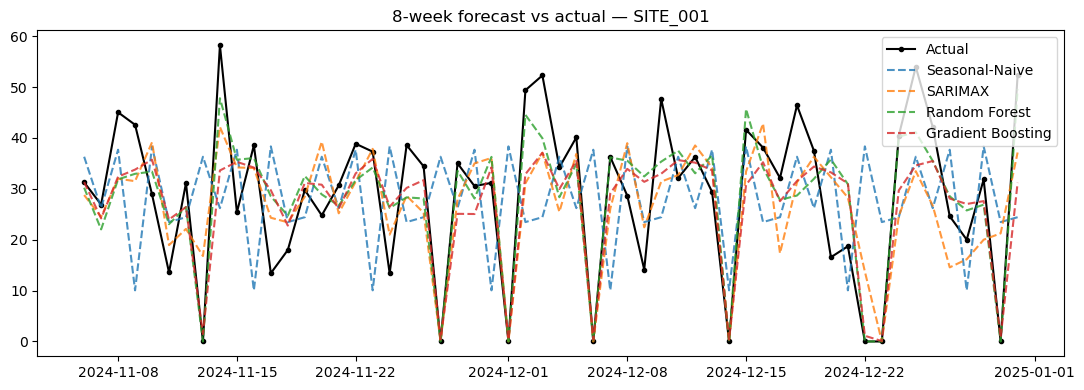

In [16]:
fig, ax = plt.subplots(figsize=(11, 4))
sample_site = sites[0]
plot_df = results[results["site_id"] == sample_site].sort_values("date")
ax.plot(plot_df["date"], plot_df["actual"], label="Actual", marker="o", markersize=3, color="black")
for name, col in model_cols.items():
    ax.plot(plot_df["date"], plot_df[col], label=name, linestyle="--", alpha=0.8)
ax.set_title(f"8-week forecast vs actual — {sample_site}")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Select and Save the Winning Model

Whichever model has the lowest overall WMAPE is selected, and checked against the brief's
target of **≤15%** (originally stated as MAPE — evaluated as WMAPE for the reason established
above).


In [17]:
winner = overall.loc[0, "model"]
winner_wmape = overall.loc[0, "WMAPE (%)"]

print(f"Selected model: {winner}")
print(f"WMAPE: {winner_wmape:.2f}%  —  {'MEETS' if winner_wmape <= 15 else 'DOES NOT MEET'} the ≤15% target")


Selected model: Random Forest
WMAPE: 17.84%  —  DOES NOT MEET the ≤15% target


In [18]:
os.makedirs("../models", exist_ok=True)

if winner == "Random Forest":
    joblib.dump(rf, "../models/demand_forecast_model.joblib")
    joblib.dump(FEATURE_COLS, "../models/feature_columns.joblib")
    print("Saved Random Forest model to ../models/demand_forecast_model.joblib")
elif winner == "Gradient Boosting":
    joblib.dump(gbm, "../models/demand_forecast_model.joblib")
    joblib.dump(FEATURE_COLS, "../models/feature_columns.joblib")
    print("Saved Gradient Boosting model to ../models/demand_forecast_model.joblib")
elif winner == "SARIMAX":
    print("SARIMAX models are fit per-site rather than saved as one object;")
    print("the fit_forecast_sarimax() function above is the reusable artifact —")
    print("re-run it per site at forecast time, or refactor to persist each site's")
    print("fitted statsmodels object individually if a saved-model deliverable is required.")
else:
    print("Seasonal-naive has no fitted parameters to save — the forecasting rule itself")
    print("(seasonal_naive_forecast() above) is the complete, reusable artifact.")

results.to_parquet("../outputs/model_comparison_results.parquet", index=False)
print("Saved forecast comparison results to ../outputs/model_comparison_results.parquet")


Saved Random Forest model to ../models/demand_forecast_model.joblib
Saved forecast comparison results to ../outputs/model_comparison_results.parquet


## Summary

| Model | Approach | Multi-step method |
|---|---|---|
| Seasonal-Naive | Repeats each site's last real week, cycled | Trivial — no fitting |
| SARIMAX | One model per site, exogenous regressors (planned pour, rain, cyclical month) | Native multi-step forecast |
| Random Forest | One global model across all sites, behaviour/region as features | Recursive |
| Gradient Boosting | One global model across all sites, behaviour/region as features | Recursive |

All four were evaluated on a genuine, non-peeking 56-day (8-week) forecast horizon, with a
leakage-free feature set that deliberately excludes same-day inventory columns, and scored on
WMAPE rather than plain MAPE, since 12.5% of test days had zero actual consumption and would
have made row-wise MAPE mathematically meaningless.

**Next notebook:** Inventory Simulation — using the winning model's forecasts to project silo
levels forward and derive per-site, per-behaviour reorder points.
